In [ ]:
import logging
import os
import pickle
import random
import sys
from os.path import join

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xgboost as xgb
from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.model_selection import KFold

sys.path.append("./additional_code")
# from data_preprocessing import *
CURRENT_DIR = os.getcwd()
print(CURRENT_DIR)
our_data = CURRENT_DIR + "/../data/our_data/"

/home/hanxd/Repositories/ESP/our_codes


In [ ]:
data = pd.read_csv(
    our_data + "geneID_ligandID_Atha_scores.txt",
    sep="\t",
    header=None,
    names=["scores_g", "Binding", "enzyme", "target", "substrate", "cc"],
)

In [4]:
data

,scores_g,Binding,enzyme,target,substrate,cc
1,0.578,False,CYP72A7,CYP706A3,ABA,C14
1,0.521,False,CYP708A2,CYP706A3,ABA,C14
1,0.641,False,CYP72A9,CYP706A3,ABA,C14
1,0.597,False,CYP71A16,CYP706A3,ABA,C14
1,0.407,False,AF-A0A178WIC4-F1-model_v4,CYP706A3,ABA,C14
...,...,...,...,...,...,...
30,0.241,False,AF-F4J5G3-F1-model_v4,CYP708A2,THA,C10
30,0.269,False,AF-O80806-F1-model_v4,CYP708A2,THA,C10
30,0.141,False,AF-O22185-F1-model_v4,CYP708A2,THA,C10
30,0.196,False,AF-O23389-F1-model_v4,CYP708A2,THA,C10


In [ ]:
df = pd.read_pickle(
    join(CURRENT_DIR, "..", "data", "our_data", "p450plant_deletedata.pkl")
)
speciesdata = pd.read_csv(our_data + "species_ligand.txt", sep="\t", header=0)
deletedata = speciesdata[speciesdata["species"] == "Arabidopsis thaliana"]
df_box = df[df["substrate"].isin(deletedata["substrate"])]

In [ ]:
df_box[df_box["substrate"] == "CAT"]

,enzyme,substrate,Binding,ESM1b,ECFP,scores
1,CYP701A26,CAT,0.0,"[-0.025068089365959167, 0.14765217900276184, -...",0100000010000000000000000000010001001000000000...,0.027256
238,CYP701A40,CAT,0.0,"[-0.023883169516921043, 0.1861409693956375, -0...",0100000010000000000000000000010001001000000000...,0.040715
475,CYP703A2,CAT,0.0,"[0.0037817787379026413, 0.11447639018297195, 0...",0100000010000000000000000000010001001000000000...,0.001448
712,CYP704B1,CAT,0.0,"[-0.16307619214057922, 0.06781131029129028, 0....",0100000010000000000000000000010001001000000000...,0.099627
949,CYP706A3,CAT,0.0,"[-0.0765826478600502, 0.1221691444516182, 0.02...",0100000010000000000000000000010001001000000000...,0.005214
...,...,...,...,...,...,...
121345,CYP94D108,CAT,0.0,"[-0.12546400725841522, 0.07352237403392792, 0....",0100000010000000000000000000010001001000000000...,0.203238
121582,CYP94N1,CAT,0.0,"[-0.09482450038194656, 0.07050970196723938, 0....",0100000010000000000000000000010001001000000000...,0.366215
121819,CYP96T1,CAT,0.0,"[-0.08144986629486084, 0.15373273193836212, 0....",0100000010000000000000000000010001001000000000...,0.256196
122056,CYP97C27,CAT,0.0,"[-0.04886553809046745, 0.04060991480946541, 0....",0100000010000000000000000000010001001000000000...,0.113430


In [ ]:
result = data.merge(
    df_box[["enzyme", "substrate", "scores"]], on=["enzyme", "substrate"], how="left"
)
result = result.dropna()

In [8]:
result

,scores_g,Binding,enzyme,target,substrate,cc,scores
0,0.578,False,CYP72A7,CYP706A3,ABA,C14,0.015472
1,0.521,False,CYP708A2,CYP706A3,ABA,C14,0.012017
2,0.641,False,CYP72A9,CYP706A3,ABA,C14,0.005075
3,0.597,False,CYP71A16,CYP706A3,ABA,C14,0.070787
6,0.451,False,CYP705A5,CYP706A3,ABA,C14,0.015274
...,...,...,...,...,...,...,...
5906,0.202,False,CYP79F2,CYP708A2,THA,C10,0.064581
5907,0.122,False,CYP71B15,CYP708A2,THA,C10,0.034653
5908,0.279,False,CYP90B1,CYP708A2,THA,C10,0.088853
5911,0.124,False,CYP79F1,CYP708A2,THA,C10,0.033550


In [ ]:
len(result[result["substrate"] == "CAT"])

57

In [ ]:
result[result["Binding"] == True]["scores"].tolist()

[0.019055025652050972,
 0.9846850633621216,
 0.9279204607009888,
 0.9851373434066772,
 0.24821744859218597,
 0.1246490404009819,
 0.11717197299003601,
 0.1246490404009819,
 0.11717197299003601,
 0.26326391100883484,
 0.8958145380020142,
 0.6820377111434937,
 0.8965671062469482,
 0.759617030620575,
 0.6935471892356873,
 0.08462411910295486,
 0.40260568261146545,
 0.7637208700180054,
 0.750740647315979,
 0.09151409566402435,
 0.9733138084411621,
 0.7622849941253662,
 0.9608287811279297,
 0.2656642496585846,
 0.41370493173599243,
 0.21730762720108032,
 0.23196226358413696,
 0.9752072691917419,
 0.41370493173599243,
 0.21730762720108032,
 0.8632445931434631,
 0.970209538936615,
 0.8632445931434631,
 0.970209538936615,
 0.00795767642557621,
 0.1392221450805664,
 0.14034096896648407,
 0.4503294825553894,
 0.987054705619812,
 0.35760781168937683,
 0.17485354840755463]

In [ ]:
print(result["enzyme"].nunique())
print(result["target"].nunique())
print(result["substrate"].nunique())

65
30
23


In [ ]:
filtered_rows = result[
    (result["Binding"] == True)
    & result["enzyme"].isin(deletedata["P450 name"])
    & result["substrate"].isin(deletedata["substrate"])
]

In [13]:
filtered_rows

,scores_g,Binding,enzyme,target,substrate,cc,scores
23,0.589,True,CYP706A3,CYP706A3,ABA,C14,0.019055
322,0.657,True,CYP716A2,CYP716A2,BAM,C23,0.984685
423,0.614,True,CYP710A1,CYP710A1,BSI,"C22,C23",0.927920
707,0.827,True,CYP85A2,CYP85A2,CAT,C12,0.248217
839,0.810,True,CYP76C2,CYP76C2,CIT,"C7,C8",0.124649
853,0.731,True,CYP76C4,CYP76C2,CIT,"C7,C8",0.117172
1063,0.810,True,CYP76C2,CYP76C4,CIT,"C7,C8",0.124649
1077,0.731,True,CYP76C4,CYP76C4,CIT,"C7,C8",0.117172
1405,0.425,True,CYP98A3,CYP98A3,COU,C14,0.263264
1489,0.706,True,CYP82G1,CYP82G1,EGE,C7,0.895815


In [ ]:
filtered_rows[filtered_rows["target"] == "CYP83A1"]

,scores_g,Binding,enzyme,target,substrate,cc,scores
5071,0.308,True,CYP83A1,CYP83A1,MBD,C2,0.139222


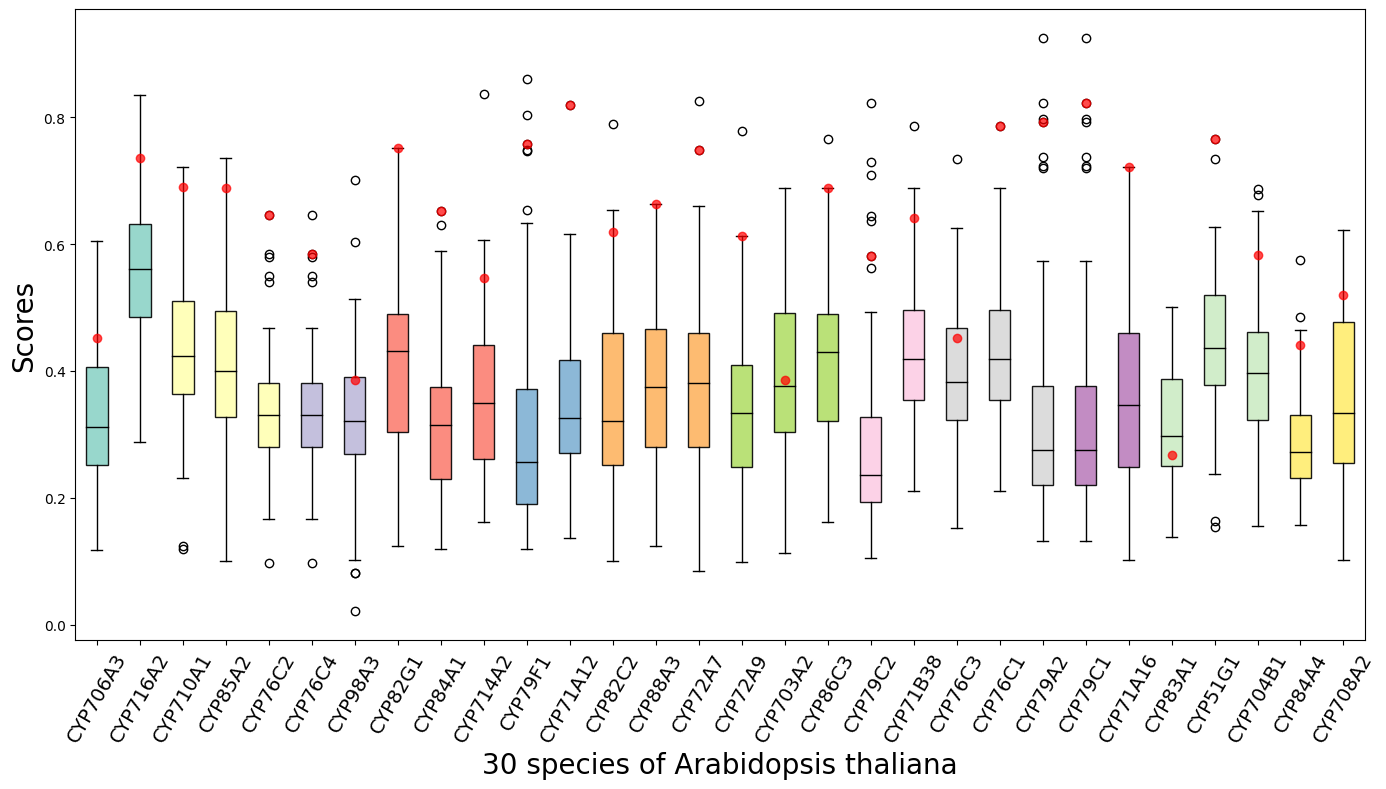

In [ ]:
# from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm

enzymes = result["target"].unique().tolist()
# substrates = [filtered_rows[(result['enzyme']==i) & (result['Binding']==True)]['substrate'].iloc[0] for i in enzymes]

data_to_plot = [
    ((100 - 76) / 100) * (result[result["target"] == substrate]["scores"])
    + (76) / 100 * (result[result["target"] == substrate]["scores_g"])
    for substrate in enzymes
]
# data_to_plot = [((100-76)/100)*(result[result['substrate'] == substrate]['scores'])+(76)/100*(result[result['substrate'] == substrate]['scores_g']) for substrate in substrates]

plt.figure(figsize=(14, 8))
cmap = cm.Set3

box = plt.boxplot(data_to_plot, positions=range(1, len(enzymes) + 1), patch_artist=True)

for i, patch in enumerate(box["boxes"]):
    patch.set_facecolor(cmap((i + 1) / (len(enzymes) + 1)))
    patch.set_alpha(0.9)

for median in box["medians"]:
    median.set_color("black")

plt.xticks(range(1, len(enzymes) + 1), enzymes, rotation=60, fontsize=14)
# plt.xticks(range(1, len(enzymes) + 1), [enzyme.replace('', '\n') for enzyme in enzymes], rotation=0, fontsize=12, linespacing=0.8)
plt.xlabel("30 species of Arabidopsis thaliana", fontsize=20)
plt.ylabel("Scores", fontsize=20)
# plt.title('Box Plot of Scores by Substrate', fontsize=20)

for i, substrate in enumerate(enzymes, start=1):
    substrate_scores = ((100 - 76) / 100) * filtered_rows[
        (filtered_rows["target"] == substrate) & (filtered_rows["enzyme"] == substrate)
    ]["scores"] + (76) / 100 * filtered_rows[
        (filtered_rows["target"] == substrate) & (filtered_rows["enzyme"] == substrate)
    ]["scores_g"]
    x_coords = [i] * len(substrate_scores)
    plt.scatter(x_coords, substrate_scores, color="red", alpha=0.7, zorder=3)

plt.tight_layout()
plt.show()